# Modality importance analysis

This notebook aims to better understand the relevance of MOL-JEPA's modalities


In [ ]:
import os
from inference import MolJEPAInference
from eval_utils import find_checkpoint_for_version
from dotenv import load_dotenv

load_dotenv()

# Load paths
CHECKPOINT_DIR = os.getenv("CHECKPOINT_DIR")
LOGS_DIR = os.getenv("LOGS_DIR")

# Important: Checkpoint file needs to match the configuration from the yaml, otherwise it will raise errors.
checkpoint_file = "/last.ckpt"
cfg = "final_jepa2.yaml"

# Option 1: Track back the stable-pretraining checkpoint for the logged run name
ckpt = find_checkpoint_for_version(f"{LOGS_DIR}/final_jepa2")
cpath = ckpt + checkpoint_file

# Option 2: Directly specify the checkpoint path
cpath = f"{CHECKPOINT_DIR}final_jepa2/checkpoints/epoch=142-step=1007864.ckpt"

# Load checkpoint
model = MolJEPAInference(checkpoint_path=cpath, cfg=cfg)
predictions, cls, embeddings, attention = model(["CCCC", "CC=C"], return_attn=True)
print("Predictions shape: ", predictions.shape)
print("Embeddings shape: ", embeddings.shape)
print("CLS shape: ", cls.shape)
print("Attention shape: ", attention[0].shape)
print(model)

# Inference LOMO

This analysis tries to understand the effect when leaving out modalities during inferences. We don't find any significant differences and conclude that most of the embeddings share the information between each other.


--- asap_potency_pIC50 (MERS-CoV Mpro) (metric=mae) ---


100%|██████████| 1/1 [00:04<00:00,  4.34s/it]


Baseline mean_test_mae: 0.7657
LOMO (leave out graph) mean_test_mae: 0.8394 | rel Δ +9.61%
LOMO (leave out ecfp) mean_test_mae: 0.7703 | rel Δ +0.60%
LOMO (leave out uma) mean_test_mae: 0.7233 | rel Δ -5.55%
LOMO (leave out boltz) mean_test_mae: 0.7668 | rel Δ +0.14%
LOMO (leave out boltz_preds) mean_test_mae: 0.8288 | rel Δ +8.23%
LOMO (leave out moe) mean_test_mae: 0.9022 | rel Δ +17.82%
LOMO (leave out bioxmol) mean_test_mae: 0.8352 | rel Δ +9.08%
LOMO (leave out chembl_targets) mean_test_mae: 0.7353 | rel Δ -3.97%
LOMO (leave out tdc_targets) mean_test_mae: 0.8210 | rel Δ +7.21%
LOMO (leave out pcba_targets) mean_test_mae: 0.9128 | rel Δ +19.20%
LOMO (leave out nabla_targets) mean_test_mae: 0.8979 | rel Δ +17.26%
LOMO (leave out xtb_targets) mean_test_mae: 0.7585 | rel Δ -0.95%

--- asap_potency_pIC50 (SARS-CoV-2 Mpro) (metric=mae) ---


100%|██████████| 1/1 [00:03<00:00,  3.98s/it]


Baseline mean_test_mae: 0.9277
LOMO (leave out graph) mean_test_mae: 0.8736 | rel Δ -5.83%
LOMO (leave out ecfp) mean_test_mae: 0.8026 | rel Δ -13.48%
LOMO (leave out uma) mean_test_mae: 0.8793 | rel Δ -5.21%
LOMO (leave out boltz) mean_test_mae: 0.8610 | rel Δ -7.19%
LOMO (leave out boltz_preds) mean_test_mae: 0.9710 | rel Δ +4.67%
LOMO (leave out moe) mean_test_mae: 1.0211 | rel Δ +10.07%
LOMO (leave out bioxmol) mean_test_mae: 0.8444 | rel Δ -8.97%
LOMO (leave out chembl_targets) mean_test_mae: 0.7792 | rel Δ -16.01%
LOMO (leave out tdc_targets) mean_test_mae: 0.7826 | rel Δ -15.64%
LOMO (leave out pcba_targets) mean_test_mae: 0.8016 | rel Δ -13.59%
LOMO (leave out nabla_targets) mean_test_mae: 0.8718 | rel Δ -6.02%
LOMO (leave out xtb_targets) mean_test_mae: 0.7456 | rel Δ -19.63%

--- asap_admet_log_HLM (metric=mae) ---


...

Baseline mean_test_mae: 0.4686
LOMO (leave out graph) mean_test_mae: 0.4690 | rel Δ +0.08%
LOMO (leave out ecfp) mean_test_mae: 0.5155 | rel Δ +10.00%
LOMO (leave out uma) mean_test_mae: 0.4515 | rel Δ -3.64%
LOMO (leave out boltz) mean_test_mae: 0.4428 | rel Δ -5.52%
LOMO (leave out boltz_preds) mean_test_mae: 0.4514 | rel Δ -3.68%
LOMO (leave out moe) mean_test_mae: 0.4723 | rel Δ +0.80%
LOMO (leave out bioxmol) mean_test_mae: 0.6063 | rel Δ +29.39%
LOMO (leave out chembl_targets) mean_test_mae: 0.4656 | rel Δ -0.65%
LOMO (leave out tdc_targets) mean_test_mae: 0.5869 | rel Δ +25.25%
LOMO (leave out pcba_targets) mean_test_mae: 0.5096 | rel Δ +8.74%
LOMO (leave out nabla_targets) mean_test_mae: 0.4653 | rel Δ -0.71%
LOMO (leave out xtb_targets) mean_test_mae: 0.4739 | rel Δ +1.13%

--- expansionrx_log_MPPB (metric=mae) ---


100%|██████████| 4/4 [00:19<00:00,  4.98s/it]


Baseline mean_test_mae: 0.3069
LOMO (leave out graph) mean_test_mae: 0.2680 | rel Δ -12.70%
LOMO (leave out ecfp) mean_test_mae: 0.2570 | rel Δ -16.27%
LOMO (leave out uma) mean_test_mae: 0.2722 | rel Δ -11.31%
LOMO (leave out boltz) mean_test_mae: 0.2820 | rel Δ -8.14%
LOMO (leave out boltz_preds) mean_test_mae: 0.2901 | rel Δ -5.49%
LOMO (leave out moe) mean_test_mae: 0.2606 | rel Δ -15.09%
LOMO (leave out bioxmol) mean_test_mae: 0.2829 | rel Δ -7.84%
LOMO (leave out chembl_targets) mean_test_mae: 0.2628 | rel Δ -14.39%
LOMO (leave out tdc_targets) mean_test_mae: 0.2892 | rel Δ -5.78%
LOMO (leave out pcba_targets) mean_test_mae: 0.2727 | rel Δ -11.16%
LOMO (leave out nabla_targets) mean_test_mae: 0.2977 | rel Δ -3.00%
LOMO (leave out xtb_targets) mean_test_mae: 0.2600 | rel Δ -15.28%

--- pxr_pEC50 (metric=mae) ---


100%|██████████| 9/9 [00:41<00:00,  4.57s/it]


Baseline mean_test_mae: 0.5204
LOMO (leave out graph) mean_test_mae: 0.5424 | rel Δ +4.24%
LOMO (leave out ecfp) mean_test_mae: 0.5004 | rel Δ -3.84%
LOMO (leave out uma) mean_test_mae: 0.5167 | rel Δ -0.71%
LOMO (leave out boltz) mean_test_mae: 0.5137 | rel Δ -1.27%
LOMO (leave out boltz_preds) mean_test_mae: 0.5482 | rel Δ +5.36%
LOMO (leave out moe) mean_test_mae: 0.5245 | rel Δ +0.80%
LOMO (leave out bioxmol) mean_test_mae: 0.5264 | rel Δ +1.15%
LOMO (leave out chembl_targets) mean_test_mae: 0.5227 | rel Δ +0.46%
LOMO (leave out tdc_targets) mean_test_mae: 0.5202 | rel Δ -0.03%
LOMO (leave out pcba_targets) mean_test_mae: 0.5303 | rel Δ +1.92%
LOMO (leave out nabla_targets) mean_test_mae: 0.5244 | rel Δ +0.77%
LOMO (leave out xtb_targets) mean_test_mae: 0.5490 | rel Δ +5.51%


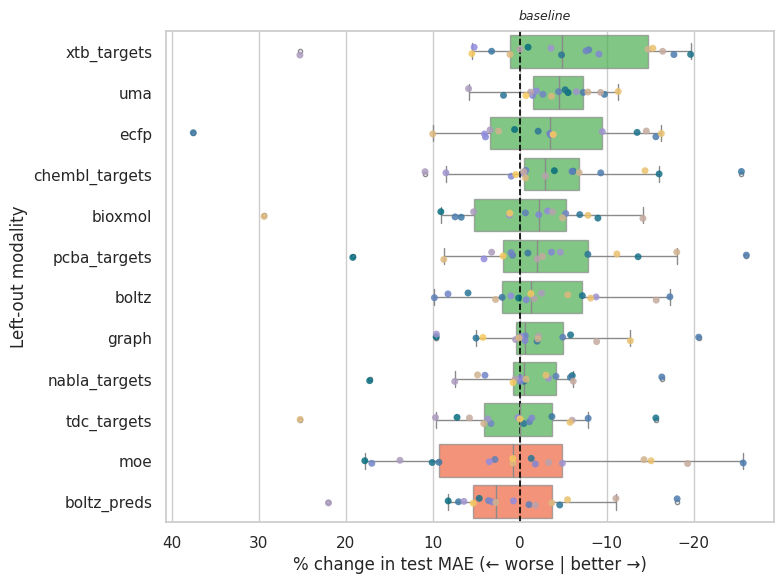

In [ ]:
import pandas as pd
import seaborn as sns
from config import PUBLIC_SPLITS
import matplotlib.pyplot as plt
import torch
from eval_utils import (
    load_public_split_data,
    featurize_dataset,
    run_torch_cross_validation,
)



public_splits = [(cat, val) for cat, values in PUBLIC_SPLITS.items() for val in values]

variant = "transformer"
split_cols = ["split1"]

all_results = []

for dataset_name, endpoint in public_splits:
    try:
        dataset = dataset_name + "_" + endpoint
        metric = "roc_auc" if dataset_name == "tox21_linz" else "mae"
        metric_key = "mean_test_roc_auc" if metric == "roc_auc" else "mean_test_mae"
        print(f"\n--- {dataset} (metric={metric}) ---")

        df = load_public_split_data(dataset_name, endpoint).dropna(subset=["y"]).copy()
        X_embeddings, X_latent, X_cls = featurize_dataset(df, model)
        X = torch.cat([X_embeddings, X_latent], dim=1)
        y = df["y"].values

        # Baseline
        baseline = run_torch_cross_validation(
            df, X, y, variant=variant, split_cols=split_cols, verbose=False, metric=metric
        )
        baseline_score = baseline[metric_key]

        print(f"Baseline {metric_key}: {baseline_score:.4f}")

        all_results.append({
            "dataset": dataset,
            "run": "baseline",
            metric_key: baseline_score,
            "rel_change_vs_baseline": 0.0,
        })

        # LOMO — only on per-modality embeddings, keep full latent
        n_mods = len(model.model.modalities_spec)
        emb_dim = X_embeddings.shape[1] // n_mods

        for i, modality in enumerate(model.model.modalities_spec):
            name = modality["name"]

            left = X_embeddings[:, : i * emb_dim]
            right = X_embeddings[:, (i + 1) * emb_dim :]

            if left.shape[1] == 0:
                X_emb_lomo = right
            elif right.shape[1] == 0:
                X_emb_lomo = left
            else:
                X_emb_lomo = torch.cat([left, right], dim=1)

            # Re-concatenate with full latent
            X_lomo = torch.cat([X_emb_lomo, X_latent], dim=1)

            result = run_torch_cross_validation(
                df,
                X_lomo,
                y,
                variant=variant,
                split_cols=split_cols,
                verbose=False,
                metric=metric,
            )

            score = result[metric_key]
            if metric == "roc_auc":
                # For ROC-AUC, lower is worse (inverted relative to MAE)
                rel_delta = (baseline_score - score) / baseline_score
            else:
                rel_delta = (score - baseline_score) / baseline_score

            all_results.append({
                "dataset": dataset,
                "run": f"leave_out_{name}",
                "left_out": name,
                metric_key: score,
                "rel_change_vs_baseline": rel_delta,
            })

            print(
                f"LOMO (leave out {name}) {metric_key}: "
                f"{score:.4f} | rel Δ {rel_delta:+.2%}"
            )
    except Exception as e:
        print(f"Error processing {dataset}: {e}")


lomo_df = pd.DataFrame(all_results)
plot_df = lomo_df[lomo_df["run"] != "baseline"].copy()

# Convert to percentage
plot_df["pct_change"] = plot_df["rel_change_vs_baseline"] * 100

# Compute median pct_change per modality and sort (highest on top)
median_order = (
    plot_df
    .groupby("left_out")["pct_change"]
    .median()
    .sort_values(ascending=True)
    .index.tolist()
)

# Median per modality for coloring
median_per_mod = plot_df.groupby("left_out")["pct_change"].median()

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Plot horizontal boxplot
sns.boxplot(
    data=plot_df,
    y="left_out",
    x="pct_change",
    order=median_order,
    orient="h",
    color="#d9d9f3",
    ax=ax,
    fliersize=3,
)

# Color boxes by median sign: positive = worse (red), negative = better (green)
for i, mod in enumerate(median_order):
    med_val = median_per_mod[mod]
    color = "#ee6541" if med_val > 0 else "#4CAF50"
    ax.patches[i].set_facecolor(color)
    ax.patches[i].set_alpha(0.7)

# Overlay individual points (no legend)
palette = sns.color_palette(
    "blend:#076d7e,#928bde,#f6c85f", n_colors=plot_df["dataset"].nunique()
)
sns.stripplot(
    data=plot_df,
    y="left_out",
    x="pct_change",
    hue="dataset",
    order=median_order,
    orient="h",
    palette=palette,
    alpha=0.85,
    size=5,
    ax=ax,
    legend=False,
)

# Baseline vertical line
ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.text(0.1, -0.7, "baseline", fontsize=9, ha="left", va="bottom", style="italic")

# Invert x-axis so that left = worse, right = better
ax.invert_xaxis()

ax.set_xlabel("% change in test MAE (← worse | better →)")
ax.set_ylabel("Left-out modality")

plt.tight_layout()
plt.show()

# Inference Feature importance

Here we use a Random Forest on the embeddings and aggregate the feature importances within each modality embedding. 

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

# Load paths
CHECKPOINT_DIR = os.getenv("CHECKPOINT_DIR")
LOGS_DIR = os.getenv("LOGS_DIR")

In [ ]:
from inference import MolJEPAInference
from eval_utils import find_checkpoint_for_version

# Important: Checkpoint file needs to match the configuration from the yaml, otherwise it will raise errors.
checkpoint_file = "/last.ckpt"
cfg = "final_jepa2.yaml"

# Option 1: Track back the stable-pretraining checkpoint for the logged run name
ckpt = find_checkpoint_for_version(f"{LOGS_DIR}/final_jepa2")
cpath = ckpt + checkpoint_file

# Option 2: Directly specify the checkpoint path
cpath = f"{CHECKPOINT_DIR}final_jepa2/checkpoints/epoch=142-step=1007864.ckpt"

# Load checkpoint
model = MolJEPAInference(checkpoint_path=cpath, cfg=cfg)
predictions, cls, embeddings, attention = model(["CCCC", "CC=C"], return_attn=True)
print("Predictions shape: ", predictions.shape)
print("Embeddings shape: ", embeddings.shape)
print("CLS shape: ", cls.shape)
print("Attention shape: ", attention[0].shape)
print(model)

In [11]:
from eval_utils import (
    process_feature_importances,
    run_rf_cross_validation,
    load_data_splits,
    featurize_dataset,
)

from config import CLUSTER_SPLITS

datasets = CLUSTER_SPLITS.keys()


importances = []
for dataset in datasets:
    split_cols = ["split1"]
    df = load_data_splits(dataset)
    print("Nan count in y: ", df["y"].isna().sum())
    df = df.dropna(subset=["y"])
    y = df["y"].values

    # Featurize
    X_embeddings, X_latent, X_cls = featurize_dataset(df, model)

    results, feature_importances = run_rf_cross_validation(
        df, X_embeddings, y, split_cols=split_cols, metric="mae"
    )

    importance_results = process_feature_importances(
        model, feature_importances, modality_size=512, split_cols=split_cols
    )

    importances.append(importance_results)

    print(dataset, importance_results)


Loaded 166 molecules from /scratch/cds/MolML/JEPA/Benchmark_Datasets_clustersplits/asap_admet/HLM/log_HLM_clustersplits.sdf
Nan count in y:  0


100%|██████████| 1/1 [00:02<00:00,  2.27s/it]


[RF] train MAE: 0.1284 ± 0.0000 / test MAE: 0.3671 ± 0.0000 | R2: 0.2909 ± 0.0000
ASAP_ADMET_HLM [[('pcba_targets', 0.2633659854511986), ('boltz', 0.11852287389480566), ('boltz_preds', 0.09906772856258172), ('nabla_targets', 0.0858372666208978), ('moe', 0.08482986959688826), ('graph', 0.07731598936541145), ('bioxmol', 0.06177076248322773), ('xtb_targets', 0.053137131801203386), ('ecfp', 0.049602162360055685), ('uma', 0.044238390880356096), ('chembl_targets', 0.03146547941655821), ('tdc_targets', 0.030846359566815352)]]
Loaded 214 molecules from /scratch/cds/MolML/JEPA/Benchmark_Datasets_clustersplits/asap_admet/KSOL/log_KSOL_clustersplits.sdf
Nan count in y:  0


100%|██████████| 1/1 [00:02<00:00,  2.31s/it]


[RF] train MAE: 0.1215 ± 0.0000 / test MAE: 0.4102 ± 0.0000 | R2: 0.2345 ± 0.0000
ASAP_ADMET_KSOL [[('bioxmol', 0.21312978546352032), ('boltz_preds', 0.11000388598493734), ('ecfp', 0.10065021361006703), ('graph', 0.09842042171824524), ('uma', 0.09301975401038275), ('moe', 0.08814946861352019), ('boltz', 0.08143380043949607), ('tdc_targets', 0.0633689602227831), ('nabla_targets', 0.044268968054309035), ('chembl_targets', 0.037977756528675695), ('pcba_targets', 0.03710078874060375), ('xtb_targets', 0.0324761966134596)]]
Loaded 203 molecules from /scratch/cds/MolML/JEPA/Benchmark_Datasets_clustersplits/asap_admet/LogD/LogD_clustersplits.sdf
Nan count in y:  0


...

[RF] train MAE: 0.1237 ± 0.0000 / test MAE: 0.2963 ± 0.0000 | R2: 0.6812 ± 0.0000
OPENADMET_MLM_CLint [[('graph', 0.3183264086068813), ('uma', 0.12048471723167667), ('ecfp', 0.09099885209043056), ('bioxmol', 0.07681790784454011), ('moe', 0.06670010587668085), ('boltz', 0.059114674329947645), ('pcba_targets', 0.05909779035224443), ('xtb_targets', 0.05739097219364235), ('boltz_preds', 0.04784627106630278), ('nabla_targets', 0.04642021317014954), ('chembl_targets', 0.033316163767008786), ('tdc_targets', 0.023485923470494996)]]
Loaded 1292 molecules from /scratch/cds/MolML/JEPA/Benchmark_Datasets_clustersplits/openadmet/MPPB/openadmet_MPPB_clustersplits.sdf
Nan count in y:  0


100%|██████████| 3/3 [00:15<00:00,  5.18s/it]


[RF] train MAE: 0.0904 ± 0.0000 / test MAE: 0.2960 ± 0.0000 | R2: 0.3180 ± 0.0000
OPENADMET_MPPB [[('boltz', 0.31014391255524276), ('boltz_preds', 0.27510349820340346), ('bioxmol', 0.07150628863810181), ('ecfp', 0.06348702054954489), ('graph', 0.05521481319257183), ('moe', 0.05037850448469877), ('xtb_targets', 0.03984220513893859), ('nabla_targets', 0.03551876311697965), ('pcba_targets', 0.033652953332429555), ('chembl_targets', 0.024678695792556278), ('uma', 0.024373662642295086), ('tdc_targets', 0.01609968235323724)]]
Loaded 4288 molecules from /scratch/cds/MolML/JEPA/benchmarks/PXR/PXR_clustersplits.sdf
Nan count in y:  0


100%|██████████| 9/9 [00:49<00:00,  5.49s/it]


[RF] train MAE: 0.1954 ± 0.0000 / test MAE: 0.5160 ± 0.0000 | R2: 0.7470 ± 0.0000
OPENADMET_PXR [[('boltz_preds', 0.420727866375478), ('boltz', 0.09884423898370039), ('uma', 0.07639923398144344), ('bioxmol', 0.06644325213678359), ('graph', 0.056235764600715915), ('ecfp', 0.05385064797111799), ('moe', 0.05201371408607007), ('pcba_targets', 0.046670512637921324), ('nabla_targets', 0.04359342805505169), ('xtb_targets', 0.04069403109763434), ('chembl_targets', 0.024631205817143436), ('tdc_targets', 0.019896104256939728)]]


In [21]:
import pandas as pd

rows = []
for ds, imp in zip(datasets, importances):
    for name, value in imp[0]:
        rows.append({"dataset": ds, "modality": name, "importance": value})

importance_df = pd.DataFrame(rows)
importance_df


,dataset,modality,importance
0,ASAP_ADMET_HLM,pcba_targets,0.263366
1,ASAP_ADMET_HLM,boltz,0.118523
2,ASAP_ADMET_HLM,boltz_preds,0.099068
3,ASAP_ADMET_HLM,nabla_targets,0.085837
4,ASAP_ADMET_HLM,moe,0.084830
...,...,...,...
271,OPENADMET_PXR,pcba_targets,0.046671
272,OPENADMET_PXR,nabla_targets,0.043593
273,OPENADMET_PXR,xtb_targets,0.040694
274,OPENADMET_PXR,chembl_targets,0.024631


In [23]:
pretty_names = {
    "boltz": "Boltz",
    "cloome": "Cloome",
    "ecfp": "ECFP",
    "bioxmol": "BioXmol",
    "pcba_targets": "PCBA",
    "graph": "Graph",
    "moe": "MOE",
    "tdc_targets": "TDC",
    "nabla_targets": "Nabla DFT",
    "xtb_targets": "XTB",
    "uma": "UMA",
    "chemgpt": "ChemGPT",
    "chembl_targets": "ChEMBL",
}

importance_df = importance_df[importance_df["modality"].isin(pretty_names.keys())]
importance_df["modality"] = importance_df["modality"].map(pretty_names)


/tmp/ipykernel_1772231/286781162.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  importance_df["modality"] = importance_df["modality"].map(pretty_names)


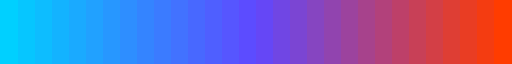

In [24]:
from matplotlib.colors import LinearSegmentedColormap

bi_cmap_bright = LinearSegmentedColormap.from_list(
    "BI_Continuous_Bright",
    [
        "#00D0FF",
        "#6048FF",
        "#FF3C00",
    ],
    N=30,
)
bi_cmap_bright


/tmp/ipykernel_1772231/3086086181.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1772231/3086086181.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x:.2f}" for x in ax.get_xticks()], fontsize=9)


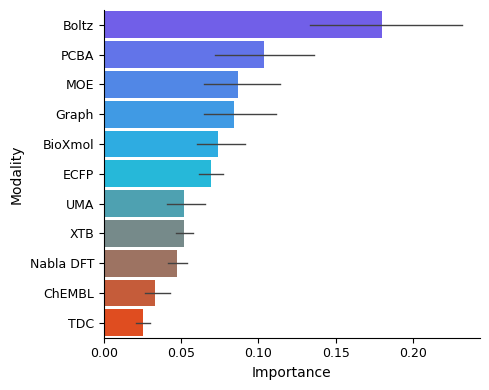

In [33]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from colors import bi_diverging_cmap

# Sort modalities by mean importance (most important on top)
modality_order = (
    importance_df
    .groupby("modality")["importance"]
    .mean()
    .sort_values(ascending=True)
    .index
)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(
    data=importance_df,
    x="importance",
    y="modality",
    order=modality_order[::-1],
    palette=sns.color_palette(bi_diverging_cmap(np.linspace(0, 1, len(modality_order)))),
    err_kws={"linewidth": 1},
    width=0.9,
    ax=ax,
)
ax.set_xticklabels([f"{x:.2f}" for x in ax.get_xticks()], fontsize=9)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()

# label
ax.set_xlabel("Importance")
ax.set_ylabel("Modality")

# Save the plot
sns.despine(ax=ax, top=True, right=True)
plt.savefig("figures/feature_importance_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### Summary plot

/tmp/ipykernel_1772231/3568251655.py:102: UserWarning: The palette list has more values (7) than needed (3), which may not be intended.
  ax = sns.barplot(


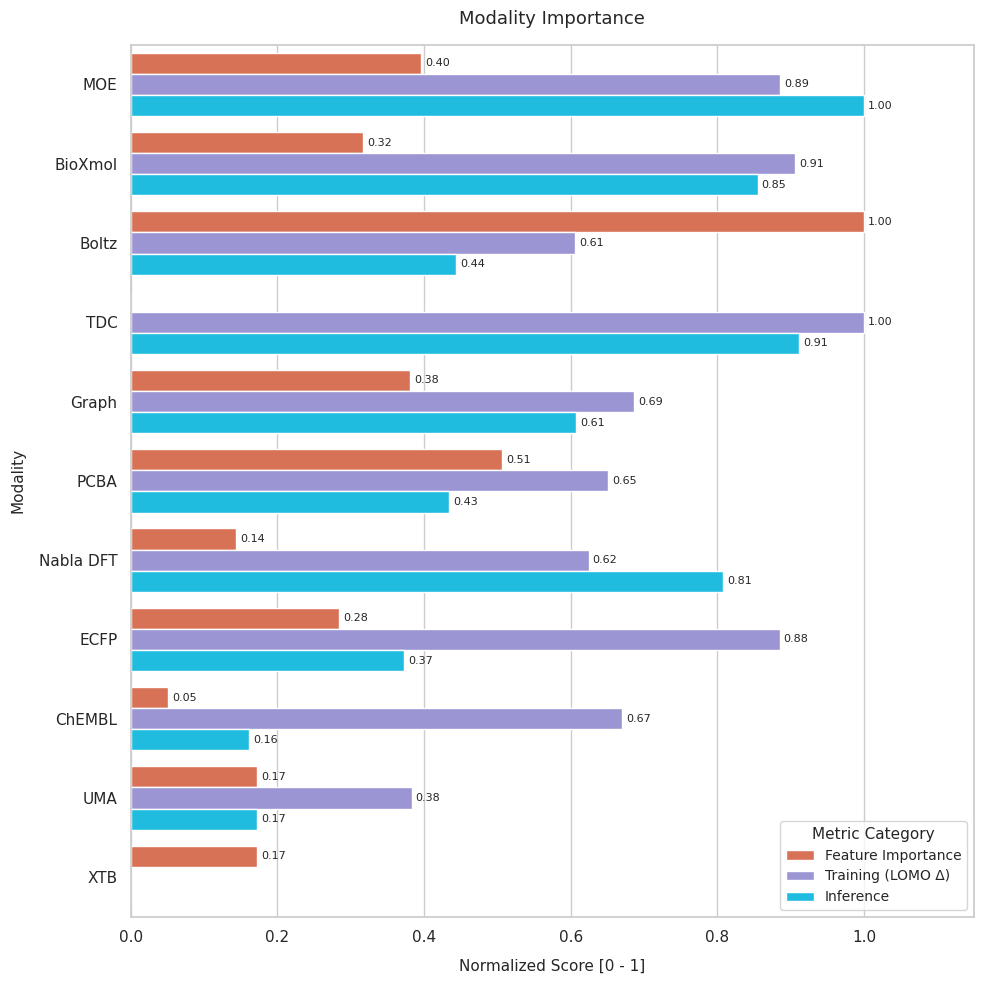

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from colors import DISCRETE_COLORS_ORIG

# Set visual style
sns.set_theme(style="whitegrid")

# Random forest feature importance values
feature_importance_raw = {
    "Boltz": 0.179570,
    "PCBA": 0.103305,
    "MOE": 0.086434,
    "Graph": 0.083948,
    "BioXmol": 0.074068,
    "ECFP": 0.069045,
    "UMA": 0.051878,
    "XTB": 0.051814,
    "Nabla DFT": 0.047356,
    "ChEMBL": 0.033054,
    "TDC": 0.025243,
}

# Inference leave one modality out analysis
inference_raw = {
    "MOE": 0.494114,
    "TDC": 0.491504,
    "BioXmol": 0.489822,
    "Nabla DFT": 0.488447,
    "Graph": 0.482510,
    "Boltz": 0.477671,
    "PCBA": 0.477393,
    "ECFP": 0.475566,
    "UMA": 0.469645,
    "ChEMBL": 0.469320,
    "XTB": 0.464554,
}

# Pretraining leave one modality out analysis
training_lomo_rel_delta = {
    "Graph": -0.806,
    "ECFP": 0.499,
    "UMA": -2.809,
    "Boltz": -1.339,
    "MOE": 0.505,
    "BioXmol": 0.635,
    "ChEMBL": -0.916,
    "TDC": 1.258,
    "PCBA": -1.042,
    "Nabla DFT": -1.218,
    "XTB": -5.333,
}

standard_keys = list(feature_importance_raw.keys())


# Min-Max Normalization Helper [0, 1]
def normalize(dictionary):
    vals = np.array([dictionary[k] for k in standard_keys])
    min_v, max_v = vals.min(), vals.max()
    norm_vals = (vals - min_v) / (max_v - min_v)
    return dict(zip(standard_keys, norm_vals))


# 2. Normalize Metrics Domain-wise
fi_norm = normalize(feature_importance_raw)
inf_norm = normalize(inference_raw)
train_norm = normalize(training_lomo_rel_delta)

# 3. Build Long-Form DataFrame
data = []
for key in standard_keys:
    data.append({
        "Modality": key,
        "Normalized Importance": fi_norm[key],
        "Metric": "Feature Importance",
    })
    data.append({
        "Modality": key,
        "Normalized Importance": train_norm[key],
        "Metric": "Training (LOMO Δ)",
    })
    data.append({
        "Modality": key,
        "Normalized Importance": inf_norm[key],
        "Metric": "Inference",
    })

df = pd.DataFrame(data)

# 4. Sort by Aggregated Mean Importance
agg_order = (
    df
    .groupby("Modality")["Normalized Importance"]
    .mean()
    .sort_values(ascending=False)
    .index
)

# 5. Plotting (Horizontal layout for vertical modality axis)
plt.figure(figsize=(10, 10))
ax = sns.barplot(
    data=df,
    y="Modality",
    x="Normalized Importance",
    hue="Metric",
    order=agg_order,
    palette=DISCRETE_COLORS_ORIG,
)

# Title & Formatting
plt.title(
    "Modality Importance",
    fontsize=13,
    pad=15,
)
plt.xlabel("Normalized Score [0 - 1]", fontsize=11, labelpad=10)
plt.ylabel("Modality", fontsize=11, labelpad=10)
plt.xlim(0, 1.15)
plt.legend(
    title="Metric Category",
    title_fontsize="11",
    fontsize="10",
    loc="lower right",
)

# Annotate exact values alongside each bar
for p in ax.patches:
    width = p.get_width()
    if not np.isnan(width) and width > 0:
        ax.annotate(
            f"{width:.2f}",
            (width, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=8,
            xytext=(3, 0),
            textcoords="offset points",
        )

plt.tight_layout()
plt.show()
